imports

In [8]:
import os
import sys
import matplotlib as mpl
import pandas as pd

sys.path.append("..")
mpl.rcParams['animation.embed_limit'] = 100

from cleanroom_cfd.config import SimulationConfig
from cleanroom_cfd.geometry import load_room_from_svg
from cleanroom_cfd.entities import Entity
from cleanroom_cfd.initial_conditions import warmup_bubble
from cleanroom_cfd.simulation import compute_time_step, cfd_step
from cleanroom_cfd.visualization import animate_simulation
import numpy as np

config and geometry

In [ ]:
cfg = SimulationConfig()

# Test run settings
cfg.sock_speed = 0.45
cfg.target_time = 120   # 2 minutes
cfg.frames = 4          # ~one frame per 30 s snapshot

svg_path = "../assets/Feynmann room_inked_good.svg"
geom = load_room_from_svg(svg_path, cfg.res)

svg_width_m = geom["svg_width_m"]
svg_height_m = geom["svg_height_m"]
grid_w = geom["grid_w"]
grid_h = geom["grid_h"]
is_obstacle = geom["is_obstacle"]

dx = 1.0 / cfg.res

hs_x = int(cfg.hotspot_x_m * cfg.res)
hs_y = int(cfg.hotspot_y_m * cfg.res)

y_start = max(1, int((cfg.y_sock_m - cfg.sock_thickness_m) * cfg.res))
y_end = min(grid_h - 2, int((cfg.y_sock_m + cfg.sock_thickness_m) * cfg.res))
y_mid = (y_start + y_end) // 2

src_half = cfg.source_half_thickness_cells
src_y0 = max(1, y_mid - src_half)
src_y1 = min(grid_h - 1, y_mid + src_half)

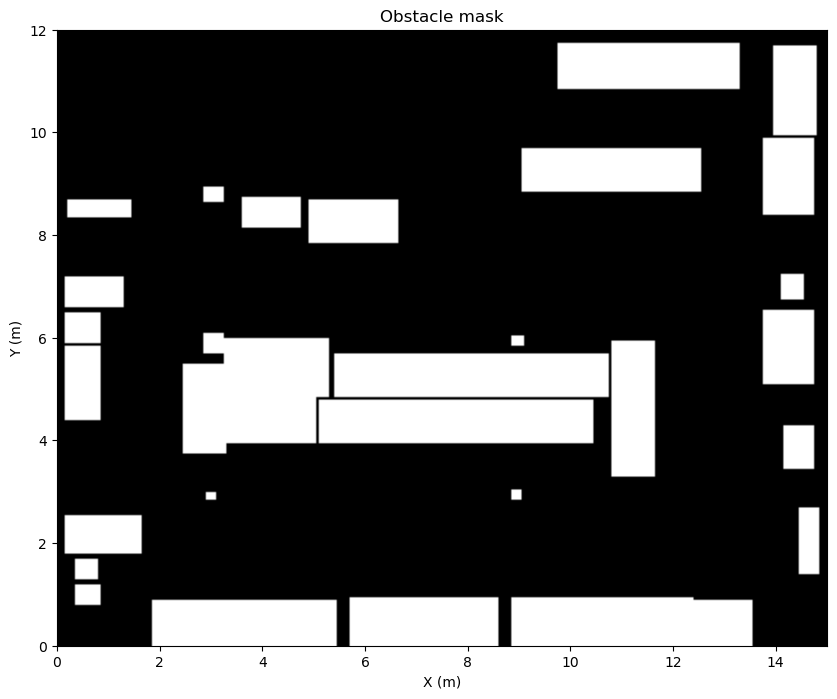

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(is_obstacle, origin="lower", extent=[0, svg_width_m, 0, svg_height_m], cmap="gray")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Obstacle mask")
plt.show()

new CSV dataset analysis + window filter cell


In [ ]:
csv_path = "../assets/integrated_projected_objects.csv"
df_all = pd.read_csv(csv_path)

df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
df_all = df_all.sort_values("timestamp").reset_index(drop=True)

# Easy control: how much of the table to simulate
table_window_minutes = 2

first_ts = df_all["timestamp"].min()
end_ts = first_ts + pd.Timedelta(minutes=table_window_minutes)

df_window = df_all[
    (df_all["timestamp"] >= first_ts) &
    (df_all["timestamp"] < end_ts)
].copy()

unique_times_window = df_window["timestamp"].drop_duplicates().sort_values().to_list()
rows_by_time_window = {
    t: grp.copy()
    for t, grp in df_window.groupby("timestamp")
}

print("Window start:", first_ts)
print("Window end:", end_ts)
print("Rows in window:", len(df_window))
print("Unique timestamps in window:", len(unique_times_window))
print("Labels in window:", sorted(df_window["canonical_label"].dropna().unique().tolist()))
print("people_or_machine values:", sorted(df_window["people_or_machine"].dropna().unique().tolist()))

new static room entities + machine builder + human builder

In [ ]:
# Static room entities that are not coming from the dataset
base_entities_list = [
    # Pressure outlets lower wall
    Entity("pressure_outlet", x_m=3.9, y_m=0.0, width_m=0.2, height_m=0.2, id_name="outlet_1"),
    Entity("pressure_outlet", x_m=5.9, y_m=0.0, width_m=0.2, height_m=0.2, id_name="outlet_2"),
    Entity("pressure_outlet", x_m=7.9, y_m=0.0, width_m=0.2, height_m=0.2, id_name="outlet_3"),
    Entity("pressure_outlet", x_m=9.9, y_m=0.0, width_m=0.2, height_m=0.2, id_name="outlet_4"),
    Entity("pressure_outlet", x_m=11.9, y_m=0.0, width_m=0.2, height_m=0.2, id_name="outlet_5"),

    # Existing passthrough furniture
    Entity("furniture_passthrough", x_m=1.8, y_m=0.0, width_m=3.6, height_m=1.0, id_name="table_1"),
    Entity("furniture_passthrough", x_m=5.7, y_m=0.0, width_m=3.9, height_m=1.0, id_name="table_2"),
    Entity("furniture_passthrough", x_m=9.8, y_m=0.0, width_m=3.8, height_m=1.0, id_name="table_3"),
]

def clamp_xy(x, y, w, h):
    x = min(max(float(x), 0.0), svg_width_m - w)
    y = min(max(float(y), 0.0), svg_height_m - h)
    return x, y

def machine_size_from_label(label):
    label = str(label).lower()
    if label == "machine":
        return 1.0, 0.6
    if label == "screen":
        return 0.8, 0.3
    if label == "cableduct":
        return 0.8, 0.3
    if label == "window":
        return 0.6, 0.4
    return 0.8, 0.5

def build_machine_entities_for_real_time(sim_time_s):
    """
    Machines are rebuilt from the current timestamp snapshot.
    First test version: snapshot-based, just like people, but with machine labels and temperatures.
    """
    if not unique_times_window:
        return []

    current_ts = first_ts + pd.Timedelta(seconds=sim_time_s)
    eligible_times = [t for t in unique_times_window if t <= current_ts]

    if not eligible_times:
        rows = rows_by_time_window[unique_times_window[0]]
    else:
        rows = rows_by_time_window[eligible_times[-1]]

    machine_rows = rows[rows["people_or_machine"].str.lower() == "machine"].copy()

    machine_entities = []
    for i, row in machine_rows.iterrows():
        label = row["canonical_label"]
        x = row["display_x"] if pd.notna(row.get("display_x")) else row["projected_x"]
        y = row["display_y"] if pd.notna(row.get("display_y")) else row["projected_y"]

        w, h = machine_size_from_label(label)
        x, y = clamp_xy(x, y, w, h)

        ent = Entity(
            "heat_source_short",
            x_m=x,
            y_m=y,
            width_m=w,
            height_m=h,
            id_name=str(row["object_id"]) if pd.notna(row.get("object_id")) else f"machine_{i}"
        )

        if pd.notna(row.get("temp_mean_c")):
            ent.temp_target = float(row["temp_mean_c"])

        machine_entities.append(ent)

    return machine_entities

def build_human_entities_for_real_time(sim_time_s):
    if not unique_times_window:
        return []

    current_ts = first_ts + pd.Timedelta(seconds=sim_time_s)
    eligible_times = [t for t in unique_times_window if t <= current_ts]

    if not eligible_times:
        rows = rows_by_time_window[unique_times_window[0]]
    else:
        rows = rows_by_time_window[eligible_times[-1]]

    human_rows = rows[rows["people_or_machine"].str.lower() == "people"].copy()

    human_entities = []
    for i, row in human_rows.iterrows():
        x = row["projected_x"]
        y = row["projected_y"]
        w, h = 0.4, 0.4
        x, y = clamp_xy(x, y, w, h)

        ent = Entity(
            "human",
            x_m=x,
            y_m=y,
            width_m=w,
            height_m=h,
            id_name=str(row["object_id"]) if pd.notna(row.get("object_id")) else f"human_{i}"
        )

        if pd.notna(row.get("temp_mean_c")):
            ent.temp_target = float(row["temp_mean_c"])

        human_entities.append(ent)

    return human_entities

initial fields

In [ ]:
thermal_grid = warmup_bubble(
    grid_h, grid_w, is_obstacle, hs_x, hs_y,
    cfg.alpha_heat, dx, cfg.warmup_steps, cfg.bubble_r
)

thermal_grid[src_y0:src_y1, 1:-1] = (
    0.65 * thermal_grid[src_y0:src_y1, 1:-1] + 0.35 * cfg.supply_temp
)

sock_tracer = np.zeros((grid_h, grid_w))
sock_tracer[src_y0:src_y1, 1:-1] = 0.9

u_vel = np.zeros((grid_h, grid_w))
v_vel = np.zeros((grid_h, grid_w))
p = np.zeros((grid_h, grid_w))

dt = compute_time_step(dx, cfg.sock_speed, cfg.alpha_heat, cfg.nu_eff)

# Real snapshots are about every 30 s
save_interval_s = 30.0
substeps_per_frame = int(save_interval_s / dt)

print("dt =", dt)
print("frames =", cfg.frames)
print("save interval (s) =", save_interval_s)
print("substeps_per_frame =", substeps_per_frame)
print("total simulated time represented =", cfg.frames * substeps_per_frame * dt)

dt = 0.012500000000000004
frames = 120
save interval (s) = 30.0
substeps_per_frame = 2399
total simulated time represented = 3598.5000000000014


step function wrapper

In [ ]:
sim_time_state = {"t": 0.0}

def step_fn(T, tracer, u, v, p):
    machine_entities = build_machine_entities_for_real_time(sim_time_state["t"])
    human_entities = build_human_entities_for_real_time(sim_time_state["t"])

    entities_list = base_entities_list + machine_entities + human_entities

    out = cfd_step(
        T, tracer, u, v, p,
        dx=dx,
        dt=dt,
        entities_list=entities_list,
        is_obstacle=is_obstacle,
        res=cfg.res,
        src_y0=src_y0,
        src_y1=src_y1,
        hs_x=hs_x,
        hs_y=hs_y,
        bubble_r=cfg.bubble_r,
        alpha_heat=cfg.alpha_heat,
        nu_eff=cfg.nu_eff,
        rho=cfg.rho,
        beta_b=cfg.beta_b,
        g=cfg.g,
        T_ref=cfg.T_ref,
        sock_speed=cfg.sock_speed,
        supply_temp=cfg.supply_temp,
        smoke_diff=cfg.smoke_diff,
        pressure_iters=cfg.pressure_iters,
        max_speed=cfg.max_speed
    )

    sim_time_state["t"] += dt
    return out

animate

In [ ]:
anim = animate_simulation(
    thermal_grid, sock_tracer, u_vel, v_vel, p,
    step_fn=step_fn,
    frames=cfg.frames,
    substeps_per_frame=substeps_per_frame,
    svg_width_m=svg_width_m,
    svg_height_m=svg_height_m,
    is_obstacle=is_obstacle,
    y_sock_m=cfg.y_sock_m,
    sock_thickness_m=cfg.sock_thickness_m,
    hs_x_m=cfg.hotspot_x_m,
    hs_y_m=cfg.hotspot_y_m,
    v_sock_target=cfg.sock_speed,
    T_supply=cfg.supply_temp,
    dt=dt,
    entities_list=base_entities_list
)